<a href="https://colab.research.google.com/github/MLfinal/Walmart-Recruiting---Store-Sales-Forecasting/blob/dev/baseline_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Walmart-ის გაყიდვების პროგნოზირება — XGBoost საბაზისო მოდელი (baseline)

ამ ნოუთბუქში ვწვრთნი (leakage-safe) გლობალურ XGBoost ის საბაზისო მოდელს.

**რა მაქვს საბაზისო მოდელში **
- ქრონოლოგიური 52-კვირიანი ვალიდაციის დაყოფა
- მაღაზიის, განყოფილების, კალენდრის, მაღაზიის მეტამონაცემების, ფასდაკლებების (markdown) და ეკონომიკური ნიშან-თვისებები (features)
- Kaggle-ის შეწონილი MAE (სადღესასწაულო რიგების წონაა 5, სხვა რიგების — 1)
- იგივე წონები გამოიყენება როგორც წვრთნის, ისე ვალიდაციის დროს
- ადრეული შეჩერება (early stopping) ვალიდაციის შეწონილ MAE-ზე დაყრდნობით
- W&B კონფიგურაცია, თითოეული იტერაციის მეტრიკები, შეჯამებული მეტრიკები, ცხრილები და არტიფაქტები

გაყიდვების lags განზრახ არის ამოღებული ამ პირველი საბაზისო მოდელიდან. ვალიდაციის ლაგები, რომლებიც აგებულია დაკვირვებად ვალიდაციის სამიზნეებზე, არ დაემთხვეოდა მრავალსაფეხურიან ტესტ-ინფერენსს და გამოიწვევდა ზედმეტად ოპტიმისტურ შედეგებს. შემდგომ ექსპერიმენტში შესაძლებელია რეკურსიული ან პირდაპირი მრავალჰორიზონტიანი ლაგების პროგნოზირების დამატება.

In [ ]:
%pip install -q "xgboost>=3.0,<4" "wandb>=0.19,<1"

In [ ]:
from __future__ import annotations

import json
import math
import os
import platform
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import wandb
import xgboost as xgb
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from wandb.integration.xgboost import WandbCallback

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "xgboost": xgb.__version__,
    "wandb": wandb.__version__,
})

{'python': '3.12.13', 'pandas': '2.2.2', 'scikit_learn': '1.6.1', 'xgboost': '3.3.0', 'wandb': '0.28.0'}


In [ ]:
CONFIG = {
    "seed": SEED,
    "validation_weeks": 52,
    "holiday_weight": 5.0,
    "objective": "reg:absoluteerror",
    "eval_metric": "mae",
    "n_estimators": 3000,
    "learning_rate": 0.03,
    "max_depth": 8,
    "min_child_weight": 5,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "early_stopping_rounds": 100,
    "tree_method": "hist",
    "device": "cuda",  # change to "cpu" when no CUDA GPU is available
    "run_final_refit": True,
    "log_dataset_artifact": True,
}

WANDB_ENTITY = "kende23-n-a"
WANDB_PROJECT = "Walmart-Recruiting---Store-Sales-Forecasting"

# In Colab this can read a WANDB_API_KEY secret; otherwise it prompts safely.
wandb.login(key=os.environ.get("WANDB_API_KEY"), relogin=False)
CONFIG

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


{'seed': 42,
 'validation_weeks': 52,
 'holiday_weight': 5.0,
 'objective': 'reg:absoluteerror',
 'eval_metric': 'mae',
 'n_estimators': 3000,
 'learning_rate': 0.03,
 'max_depth': 8,
 'min_child_weight': 5,
 'subsample': 0.85,
 'colsample_bytree': 0.85,
 'reg_alpha': 0.0,
 'reg_lambda': 1.0,
 'early_stopping_rounds': 100,
 'tree_method': 'hist',
 'device': 'cuda',
 'run_final_refit': True,
 'log_dataset_artifact': True}

## 3. მონაცემების ჩატვირთვა და ვალიდაცია

In [ ]:
import pandas as pd
from pathlib import Path

# გასწორებული გზა სწორი დასახელებით
DATA_DIR = Path('/content/drive/MyDrive/walmart_competition_data')
OUTPUT_DIR = Path('/content/artifacts/xgboost_baseline')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# მონაცემების ჩატვირთვა
train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"])
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])
features = pd.read_csv(DATA_DIR / "features.csv", parse_dates=["Date"])
stores = pd.read_csv(DATA_DIR / "stores.csv")

# ვალიდაცია
required_train = {"Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"}
required_test = {"Store", "Dept", "Date", "IsHoliday"}
required_features = {"Store", "Date", "IsHoliday"}
required_stores = {"Store", "Type", "Size"}

assert required_train.issubset(train_raw.columns)
assert required_test.issubset(test_raw.columns)
assert required_features.issubset(features.columns)
assert required_stores.issubset(stores.columns)
assert not train_raw.duplicated(["Store", "Dept", "Date"]).any()
assert not test_raw.duplicated(["Store", "Dept", "Date"]).any()

display(pd.DataFrame({
    "rows": [len(train_raw), len(test_raw), len(features), len(stores)],
    "min_date": [train_raw.Date.min(), test_raw.Date.min(), features.Date.min(), pd.NaT],
    "max_date": [train_raw.Date.max(), test_raw.Date.max(), features.Date.max(), pd.NaT],
}, index=["train", "test", "features", "stores"]))

,rows,min_date,max_date
train,421570,2010-02-05,2012-10-26
test,115064,2012-11-02,2013-07-26
features,8190,2010-02-05,2013-07-26
stores,45,NaT,NaT


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4. Feature engineering


ტრანსფორმაცია იყენებს მხოლოდ იმ სვეტებს, რომლებიც ხელმისაწვდომია როგორც საწვრთნელი, ისე სატესტო მონაცემებისთვის. XGBoost ავტომატურად ამუშავებს რიცხვით გამოტოვებულ მნიშვნელობებს. მაღაზიის ტიპი გარდაიქმნება სტაბილურ მთელ რიცხვებად; სამიზნე ენკოდირება (target encoding) არ გამოიყენება.

In [ ]:
TYPE_MAP = {"A": 0, "B": 1, "C": 2}

def build_features(
    sales_frame: pd.DataFrame,
    external: pd.DataFrame,
    store_metadata: pd.DataFrame,
) -> pd.DataFrame:
    # მონაცემების ასლის შექმნა
    frame = sales_frame.copy()
    external_no_holiday = external.drop(columns="IsHoliday")

    # ცხრილების გაერთიანება
    frame = frame.merge(
        external_no_holiday,
        on=["Store", "Date"],
        how="left",
        validate="many_to_one",
    )
    frame = frame.merge(store_metadata, on="Store", how="left", validate="many_to_one")

    # დროის ნიშან-თვისებების გენერაცია
    iso = frame["Date"].dt.isocalendar()
    frame["Year"] = frame["Date"].dt.year.astype("int16")
    frame["Month"] = frame["Date"].dt.month.astype("int8")
    frame["WeekOfYear"] = iso.week.astype("int8")
    frame["Quarter"] = frame["Date"].dt.quarter.astype("int8")
    frame["DaysFromStart"] = (frame["Date"] - pd.Timestamp("2010-02-05")).dt.days.astype("int16")

    # ციკლური ენკოდირება დროისთვის
    frame["WeekSin"] = np.sin(2 * np.pi * frame["WeekOfYear" ] / 52.0)
    frame["WeekCos"] = np.cos(2 * np.pi * frame["WeekOfYear"] / 52.0)

    # ფასდაკლებების ჯამი
    frame["TotalMarkDown"] = frame[
        ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
    ].sum(axis=1, min_count=1)

    # კატეგორიული ცვლადების გარდაქმნა
    frame["Type"] = frame["Type"].map(TYPE_MAP).astype("int8")
    frame["IsHoliday"] = frame["IsHoliday"].astype("int8")

    return frame.sort_values(["Date", "Store", "Dept"]).reset_index(drop=True)

train = build_features(train_raw, features, stores)
test = build_features(test_raw, features, stores)

NON_FEATURE_COLUMNS = {"Date", "Weekly_Sales"}
FEATURE_COLUMNS = [column for column in train.columns if column not in NON_FEATURE_COLUMNS]
print(f"ნიშან-თვისებების რაოდენობა: {len(FEATURE_COLUMNS)}")

ნიშან-თვისებების რაოდენობა: 22


## 5. ქრონოლოგიური დაყოფა და მეტრიკა

ბოლო 52 კვირა ქმნის ვალიდაციის სიმრავლეს. ეს მოიცავს 2011 წლის მადლიერების დღისა და შობის პერიოდს, ამასთანავე ვალიდაციის ყველა თარიღი მკაცრად გვიანია საწვრთნელ თარიღებზე.

In [ ]:
def weighted_mae(
    y_true: np.ndarray | pd.Series,
    y_pred: np.ndarray | pd.Series,
    is_holiday: np.ndarray | pd.Series,
    holiday_weight: float = 5.0,
) -> float:
    # შეწონილი MAE-ს გამოთვლა: სადღესასწაულო დღეებს მეტი წონა აქვს
    weights = np.where(np.asarray(is_holiday, dtype=bool), holiday_weight, 1.0)
    return float(np.average(np.abs(np.asarray(y_true) - np.asarray(y_pred)), weights=weights))

# ქრონოლოგიური დაყოფა (ბოლო 52 კვირა ვალიდაციისთვის)
validation_start = train["Date"].max() - pd.Timedelta(weeks=CONFIG["validation_weeks"] - 1)
train_mask = train["Date"] < validation_start
valid_mask = ~train_mask

X_train = train.loc[train_mask, FEATURE_COLUMNS]
y_train = train.loc[train_mask, "Weekly_Sales"]
X_valid = train.loc[valid_mask, FEATURE_COLUMNS]
y_valid = train.loc[valid_mask, "Weekly_Sales"]

# წონების მომზადება მოდელისთვის
w_train = np.where(train.loc[train_mask, "IsHoliday"].to_numpy(dtype=bool), CONFIG["holiday_weight"], 1.0)
w_valid = np.where(train.loc[valid_mask, "IsHoliday"].to_numpy(dtype=bool), CONFIG["holiday_weight"], 1.0)

split_summary = {
    "train_rows": len(X_train),
    "valid_rows": len(X_valid),
    "train_start": str(train.loc[train_mask, "Date"].min().date()),
    "train_end": str(train.loc[train_mask, "Date"].max().date()),
    "valid_start": str(train.loc[valid_mask, "Date"].min().date()),
    "valid_end": str(train.loc[valid_mask, "Date"].max().date()),
    "feature_count": len(FEATURE_COLUMNS),
}
split_summary

{'train_rows': 267184,
 'valid_rows': 154386,
 'train_start': '2010-02-05',
 'train_end': '2011-10-28',
 'valid_start': '2011-11-04',
 'valid_end': '2012-10-26',
 'feature_count': 22}

## 6. W&B გაშვების დაწყება

ორიგინალი CSV ფაილები აღირიცხება როგორც ვერსიირებული მონაცემთა არტიფაქტი.

In [ ]:
# W&B-ის ინიციალიზაცია
run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    job_type="train",
    name="xgboost-static-baseline",
    tags=["baseline", "xgboost", "time-split", "wmae"],
    config={**CONFIG, **split_summary, "features": FEATURE_COLUMNS},
    save_code=True,
)

# მონაცემების არტიფაქტად შენახვა
if CONFIG["log_dataset_artifact"]:
    dataset_artifact = wandb.Artifact(
        name="walmart-recruiting-raw-data",
        type="dataset",
        description="Raw Kaggle Walmart recruiting CSV files used by the baseline.",
        metadata=split_summary,
    )
    for filename in ["train.csv", "test.csv", "features.csv", "stores.csv"]:
        dataset_artifact.add_file(DATA_DIR / filename, name=filename)
    run.log_artifact(dataset_artifact, aliases=["latest"])

run

## 7. Sanity benchmark

საწვრთნელი პერიოდის მაღაზიის/განყოფილების მედიანა გვაძლევს კონტექსტს XGBoost-ის ქულისთვის. უცნობი წყვილებისთვის გამოიყენება დეპარტამენტის მედიანა, ხოლო შემდეგ გლობალური მედიანა.

In [ ]:
# საბაზისო პროგნოზი მედიანის გამოყენებით (Sanity Check)
history = train.loc[train_mask, ["Store", "Dept", "Weekly_Sales"]]
valid_keys = train.loc[valid_mask, ["Store", "Dept"]]

# გამოვთვალოთ მედიანა მაღაზიისა და განყოფილების მიხედვით
pair_median = history.groupby(["Store", "Dept"])["Weekly_Sales"].median()
dept_median = history.groupby("Dept")["Weekly_Sales"].median()
global_median = float(history["Weekly_Sales"].median())

naive_pred = pd.Series(
    [pair_median.get((store, dept), np.nan) for store, dept in valid_keys.itertuples(index=False)],
    index=valid_keys.index,
    dtype="float64",
)

# შევავსოთ გამოტოვებული მნიშვნელობები ზოგადი მედიანებით
naive_pred = naive_pred.fillna(valid_keys["Dept"].map(dept_median)).fillna(global_median)
naive_wmae = weighted_mae(
    y_valid,
    naive_pred,
    train.loc[valid_mask, "IsHoliday"],
    CONFIG["holiday_weight"],
)

# შემოწმება: არის თუ არა W&B სესია აქტიური ლოგირებისთვის
if 'run' in globals() and run is not None:
    run.log({"baseline/validation_wmae": naive_wmae})

print(f"მედიანური პროგნოზის ვალიდაციის WMAE: {naive_wmae:,.2f}")

მედიანური პროგნოზის ვალიდაციის WMAE: 3,305.52


## 8. XGBoost-ის გაწვრთნა

XGBoost-ის ვალიდაციის MAE არის შეჯიბრის WMAE.

In [ ]:
model_params = {
    key: CONFIG[key]
    for key in [
        "objective", "eval_metric", "n_estimators", "learning_rate", "max_depth",
        "min_child_weight", "subsample", "colsample_bytree", "reg_alpha", "reg_lambda",
        "early_stopping_rounds", "tree_method", "device",
    ]
}

# XGBoost რეგრესორის ინიციალიზაცია (დარწმუნდით, რომ wandb.run აქტიურია)
callbacks = []
if 'run' in globals() and wandb.run is not None:
    callbacks.append(
        WandbCallback(
            log_model=False,
            log_feature_importance=True,
            importance_type="gain",
            define_metric=True,
        )
    )

model = xgb.XGBRegressor(
    **model_params,
    random_state=CONFIG["seed"],
    n_jobs=-1,
    callbacks=callbacks,
)

# მოდელის წვრთნა
model.fit(
    X_train,
    y_train,
    sample_weight=w_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    sample_weight_eval_set=[w_train, w_valid],
    verbose=50,
)

print(f"საუკეთესო იტერაცია: {model.best_iteration}")
print(f"XGBoost-ის საუკეთესო ვალიდაციის WMAE: {model.best_score:,.2f}")

[0]	validation_0-mae:13362.17774	validation_1-mae:13924.37303
[50]	validation_0-mae:6745.22701	validation_1-mae:7408.66471
[100]	validation_0-mae:4907.04938	validation_1-mae:5607.13342
[150]	validation_0-mae:4191.61383	validation_1-mae:4920.33341
[200]	validation_0-mae:3843.82951	validation_1-mae:4592.05723
[250]	validation_0-mae:3662.86914	validation_1-mae:4436.70315
[300]	validation_0-mae:3484.39923	validation_1-mae:4270.90612
[350]	validation_0-mae:3294.91166	validation_1-mae:4106.67680
[400]	validation_0-mae:3144.08157	validation_1-mae:3976.53619
[450]	validation_0-mae:3019.24170	validation_1-mae:3866.36461
[500]	validation_0-mae:2898.60272	validation_1-mae:3766.20689
[550]	validation_0-mae:2787.24747	validation_1-mae:3674.41054
[600]	validation_0-mae:2711.61425	validation_1-mae:3612.30585
[650]	validation_0-mae:2648.13998	validation_1-mae:3561.30897
[700]	validation_0-mae:2589.80132	validation_1-mae:3516.89562
[750]	validation_0-mae:2536.14979	validation_1-mae:3473.01820
[800]	val

## 9. შეფასება და დიაგნოსტიკის აღრიცხვა

In [ ]:
# პროგნოზირება ვალიდაციის სიმრავლეზე
valid_pred = model.predict(X_valid)
valid_holiday = train.loc[valid_mask, "IsHoliday"].to_numpy(dtype=bool)

# მეტრიკების გამოთვლა
metrics = {
    "validation/wmae": weighted_mae(y_valid, valid_pred, valid_holiday, CONFIG["holiday_weight"]),
    "validation/mae": float(mean_absolute_error(y_valid, valid_pred)),
    "validation/rmse": float(math.sqrt(mean_squared_error(y_valid, valid_pred))),
    "validation/holiday_mae": float(mean_absolute_error(y_valid[valid_holiday], valid_pred[valid_holiday])),
    "validation/non_holiday_mae": float(mean_absolute_error(y_valid[~valid_holiday], valid_pred[~valid_holiday])),
    "validation/improvement_over_median_pct": float(
        100 * (naive_wmae - weighted_mae(y_valid, valid_pred, valid_holiday, CONFIG["holiday_weight"])) / naive_wmae
    ),
    "model/best_iteration": int(model.best_iteration),
    "model/best_score": float(model.best_score),
}

if 'run' in globals() and run is not None:
    run.log(metrics)
    run.summary.update(metrics)

# შედეგების მომზადება ცხრილისთვის
validation_results = train.loc[
    valid_mask, ["Store", "Dept", "Date", "IsHoliday", "Weekly_Sales"]
].copy()
validation_results["Prediction"] = valid_pred
validation_results["AbsoluteError"] = np.abs(
    validation_results["Weekly_Sales"] - validation_results["Prediction"]
)
validation_results["Date"] = validation_results["Date"].dt.strftime("%Y-%m-%d")

display(pd.Series(metrics, name="value").to_frame())

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [15:29:47] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,value
validation/wmae,2902.289158
validation/mae,2727.652513
validation/rmse,6654.003295
validation/holiday_mae,3464.407683
validation/non_holiday_mae,2665.610790
validation/improvement_over_median_pct,12.198589
model/best_iteration,2999.000000
model/best_score,2902.289310


,feature,importance
0,Dept,0.165267
1,Size,0.162520
2,Type,0.151315
3,Store,0.078760
4,Unemployment,0.052802
5,WeekCos,0.052796
6,CPI,0.052632
7,WeekOfYear,0.044169
8,Month,0.037758
9,WeekSin,0.035637


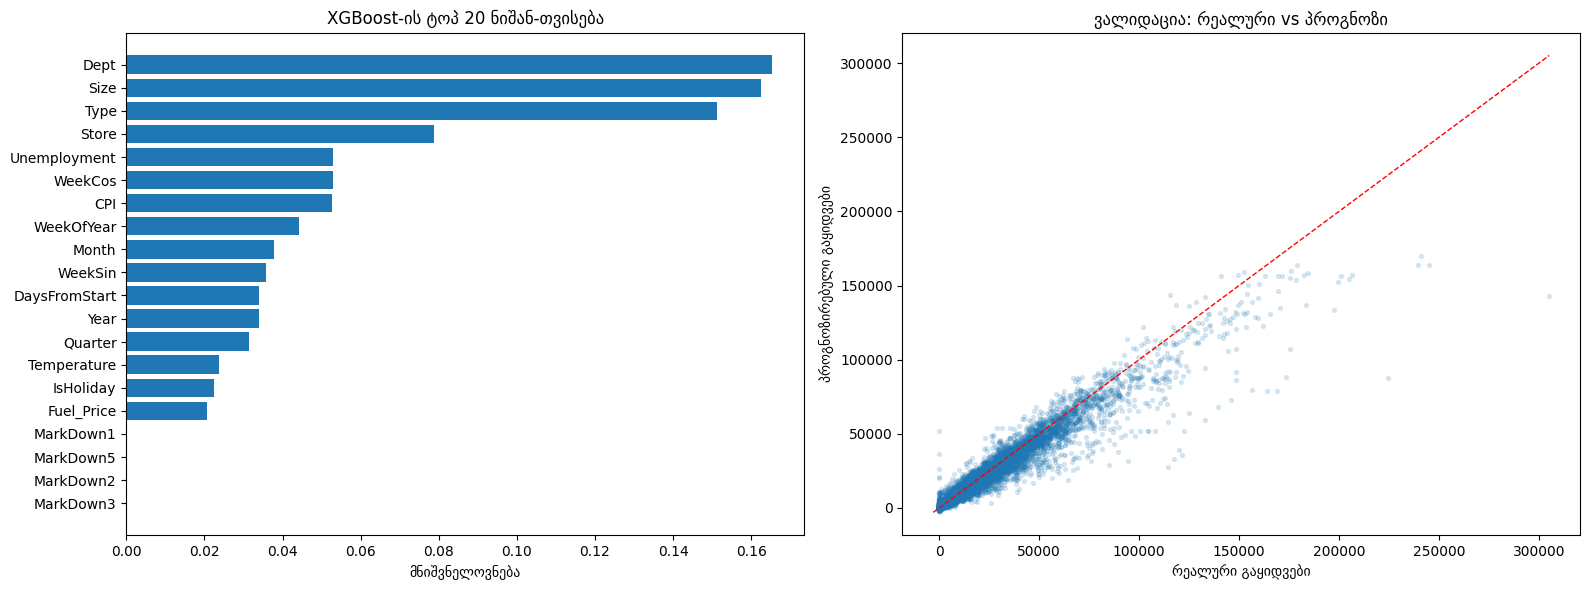

In [ ]:
# ნიშან-თვისებების მნიშვნელოვნების (feature importance) გამოთვლა
importance = (
    pd.DataFrame({"feature": FEATURE_COLUMNS, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
display(importance.head(20))

# ვიზუალიზაცია
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top = importance.head(20).sort_values("importance")
axes[0].barh(top["feature"], top["importance"])
axes[0].set_title("XGBoost-ის ტოპ 20 ნიშან-თვისება")
axes[0].set_xlabel("მნიშვნელოვნება")

# რეალური და პროგნოზირებული გაყიდვების შედარება
# ვიყენებთ p6q7rdbSgv4w უჯრედში უკვე მომზადებულ validation_results ცვლადს
sample = validation_results.sample(min(15000, len(validation_results)), random_state=SEED)
axes[1].scatter(sample["Weekly_Sales"], sample["Prediction"], alpha=0.15, s=8)
limits = [sample[["Weekly_Sales", "Prediction"]].min().min(), sample[["Weekly_Sales", "Prediction"]].max().max()]
axes[1].plot(limits, limits, "r--", linewidth=1)
axes[1].set_title("ვალიდაცია: რეალური vs პროგნოზი")
axes[1].set_xlabel("რეალური გაყიდვები")
axes[1].set_ylabel("პროგნოზირებული გაყიდვები")
plt.tight_layout()

if 'run' in globals() and run is not None:
    run.log({"validation/diagnostics": wandb.Image(fig)})
plt.show()

## 10. ვალიდაციის მოდელის შენახვა და აღრიცხვა

JSON არის XGBoost-ის სტაბილური მოდელის ფორმატი. ნიშან-თვისებების თანმიმდევრობა და მეტამონაცემები ინახება მასთან ერთად, შემდეგ კი ყველა ფაილი აღირიცხება როგორც ერთი მოდელის არტიფაქტი.

In [ ]:
# მეტრიკების ხელახალი შემოწმება/გამოთვლა NameError-ის თავიდან ასაცილებლად
if 'metrics' not in globals():
    metrics = {
        "validation/wmae": weighted_mae(y_valid, valid_pred, valid_holiday, CONFIG["holiday_weight"]),
        "validation/improvement_over_median_pct": float(100 * (naive_wmae - weighted_mae(y_valid, valid_pred, valid_holiday, CONFIG["holiday_weight"])) / naive_wmae)
    }

# ფაილების გზების განსაზღვრა
model_path = OUTPUT_DIR / "xgboost_baseline_validation.json"
feature_path = OUTPUT_DIR / "feature_columns.json"
importance_path = OUTPUT_DIR / "feature_importance.csv"
metrics_path = OUTPUT_DIR / "validation_metrics.json"

# მოდელისა და მეტამონაცემების შენახვა
model.save_model(model_path)
feature_path.write_text(json.dumps(FEATURE_COLUMNS, indent=2))
importance.to_csv(importance_path, index=False)
metrics_path.write_text(json.dumps(metrics, indent=2))

# W&B არტიფაქტის შექმნა და აღრიცხვა
if 'run' in globals() and run is not None:
    model_artifact = wandb.Artifact(
        name="xgboost-static-baseline",
        type="model",
        description="Leakage-safe XGBoost baseline trained with a chronological validation split.",
        metadata={**metrics, **split_summary},
    )
    model_artifact.add_dir(str(OUTPUT_DIR))
    run.log_artifact(model_artifact, aliases=["validation", "latest"])

print(f"მოდელის ფაილები შენახულია აქ: {OUTPUT_DIR}")

wandb: Adding directory to artifact (/content/artifacts/xgboost_baseline)... Done. 0.2s


მოდელის ფაილები შენახულია აქ: /content/artifacts/xgboost_baseline


## 11. არასავალდებულო საბოლოო გადამზადება და Kaggle-ზე წარდგენა

ეს კკოდი არაფერს აკეთებს, სანამ `CONFIG["run_final_refit"]` არის `False`. გააქტიურების შემთხვევაში, ის იყენებს საუკეთესო ვალიდაციის იტერაციების რაოდენობას, ხელახლა წვრთნის მოდელს ყველა მონაცემზე, წერს პროგნოზებს Kaggle-ის ფორმატში `Store_Dept_Date,Weekly_Sales` და აღრიცხავს საბოლოო მოდელს.

In [ ]:
if CONFIG["run_final_refit"]:
    # საბოლოო მოდელის წვრთნა ყველა მონაცემზე
    final_rounds = int(model.best_iteration) + 1
    final_params = {
        key: value
        for key, value in model_params.items()
        if key not in {"n_estimators", "early_stopping_rounds"}
    }
    final_model = xgb.XGBRegressor(
        **final_params,
        n_estimators=final_rounds,
        random_state=CONFIG["seed"],
        n_jobs=-1,
    )
    all_weights = np.where(train["IsHoliday"].to_numpy(dtype=bool), CONFIG["holiday_weight"], 1.0)
    final_model.fit(train[FEATURE_COLUMNS], train["Weekly_Sales"], sample_weight=all_weights, verbose=False)

    # ტესტური პროგნოზების მომზადება Kaggle-სთვის
    test_pred = final_model.predict(test[FEATURE_COLUMNS])
    submission = pd.DataFrame({
        "Id": (
            test_raw["Store"].astype(str)
            + "_" + test_raw["Dept"].astype(str)
            + "_" + test_raw["Date"].dt.strftime("%Y-%m-%d")
        ),
        "Weekly_Sales": test_pred,
    })

    # შედეგების შენახვა
    final_model_path = OUTPUT_DIR / "xgboost_baseline_final.json"
    submission_path = OUTPUT_DIR / "submission_xgboost_baseline.csv"
    final_model.save_model(final_model_path)
    submission.to_csv(submission_path, index=False)

    if 'run' in globals() and run is not None:
        final_artifact = wandb.Artifact(
            name="xgboost-static-baseline-final",
            type="model",
            metadata={"n_estimators": final_rounds, "training_rows": len(train)},
        )
        final_artifact.add_file(str(final_model_path))
        final_artifact.add_file(str(feature_path))
        final_artifact.add_file(str(submission_path))
        run.log_artifact(final_artifact, aliases=["production-candidate", "latest"])

    print(f"საბოლოო ფაილი შენახულია: {submission_path}")
else:
    print("საბოლოო გადამზადება გამოტოვებულია. შეცვალეთ CONFIG['run_final_refit'] = True მის გასაშვებად.")

საბოლოო ფაილი შენახულია: /content/artifacts/xgboost_baseline/submission_xgboost_baseline.csv


## 12. W&B გაშვების დასრულება

ყოველთვის დაასრულეთ გაშვება (run), რათა მოხდეს დარჩენილი მეტრიკებისა და არტიფაქტების ატვირთვა.

In [ ]:
run.finish()

best_iteration,▁
best_score,▁
epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▆▆▆▆▇▇▇▇▇▇▇▇█████
model/best_iteration,▁
model/best_score,▁
validation/holiday_mae,▁
validation/improvement_over_median_pct,▁
validation/mae,▁
validation/non_holiday_mae,▁
validation/rmse,▁
+3,...
